## Análise Exploratória de Dados (EDA)

O objetivo desse notebook é verificar a consistência dos dados, identificar possíveis problemas de qualidade e definir as transformações necessárias para a construção da camada de modelagem.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/kaggle/selected-dataset.csv", sep=";")

df.shape

(41188, 21)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

As variáveis apresentaram tipos compatíveis com sua natureza, não será necessária conversão de tipos durante o carregamento da base.

In [ ]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Não há valores nulos.

In [3]:
df.duplicated().sum()

np.int64(12)

Há 12 registros duplicados, como não agregam novas informações para o processo de modelagem e podem introduzir viés nas análises, podem ser removiso durante no processamento do arquivo final.

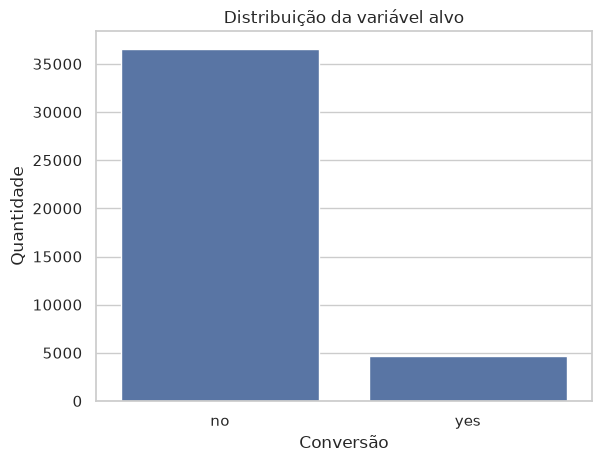

In [ ]:
#Distribuição da variável alvo
df["y"].value_counts()
(df["y"].value_counts(normalize=True) * 100).round(2)
sns.countplot(data=df, x="y")
plt.title("Distribuição da variável alvo")
plt.xlabel("Conversão")
plt.ylabel("Quantidade")
plt.show()

Há predominância da classe "no", característica esperada em campanhas de marketing bancário.
Como o objetivo do projeto não é treinar um classificador supervisionado, mas sim um algoritmo de Contextual Multi-Armed Bandit, esse desbalanceamento não inviabiliza o problema proposto.

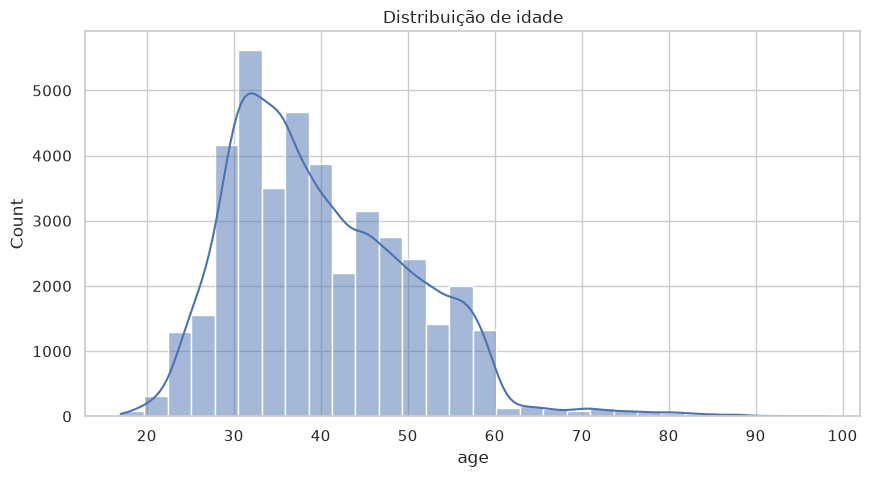

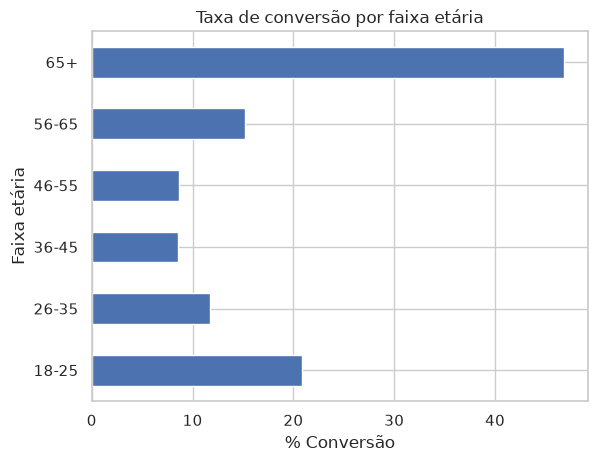

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
98       2
89       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64

In [ ]:
#Distribuição de idade
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribuição de idade")
plt.show()

df["faixa_etaria"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

conv_idade = (
    pd.crosstab(
        df["faixa_etaria"],
        df["y"],
        normalize="index"
    )["yes"]
    * 100
)

conv_idade.plot(kind="barh")

plt.title("Taxa de conversão por faixa etária")
plt.xlabel("% Conversão")
plt.ylabel("Faixa etária")
plt.show()

A variável age apresenta alguns valores extremos, considerados outliers, principalmente clientes com idade superior a 80 anos.
Esses registros foram mantidos por serem plausíveis dentro do contexto do domínio bancário e por não representarem erros aparentes de coleta.

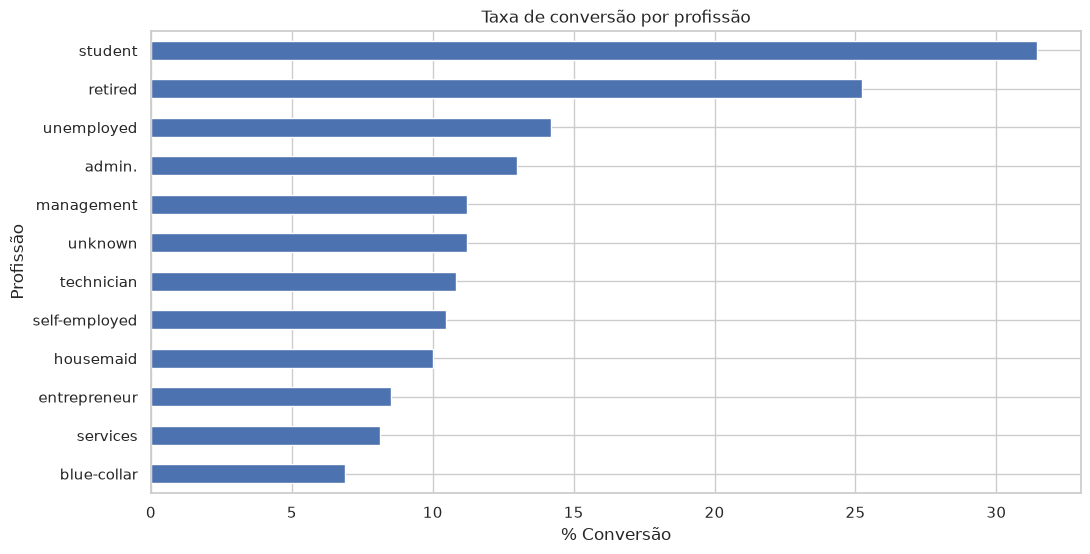

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [ ]:
#Taxa de conversão por profissão
plt.figure(figsize=(12,6))

(
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    )["yes"]
    *100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por profissão")
plt.xlabel("% Conversão")
plt.ylabel("Profissão")
plt.show()

df["job"].value_counts()

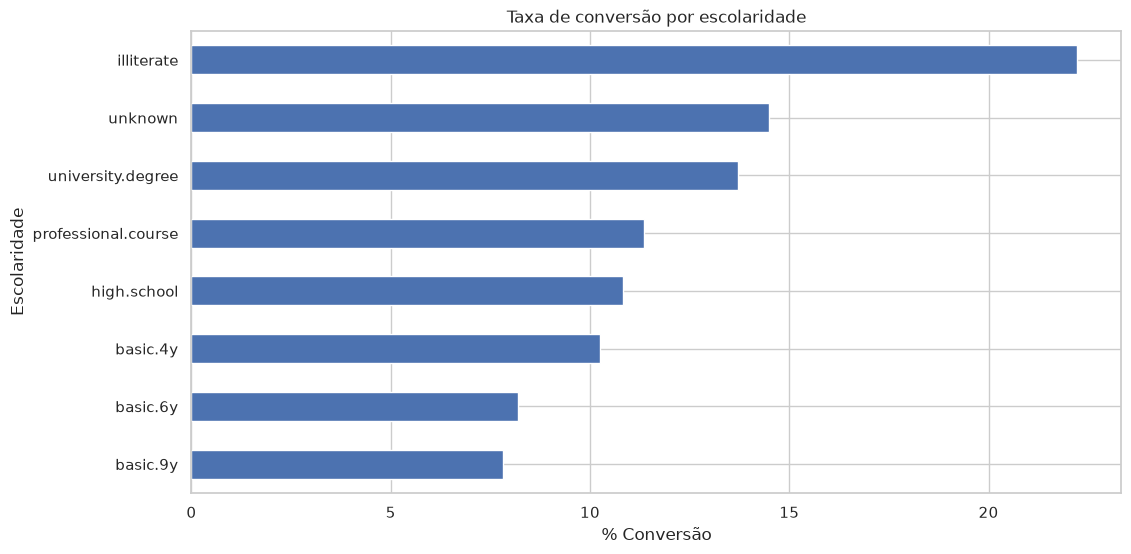

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [ ]:
#Taxa de conversão por escolaridade
plt.figure(figsize=(12,6))

(
    pd.crosstab(
        df["education"],
        df["y"],
        normalize="index"
    )["yes"]
    *100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por escolaridade")
plt.xlabel("% Conversão")
plt.ylabel("Escolaridade")
plt.show()

df["education"].value_counts()

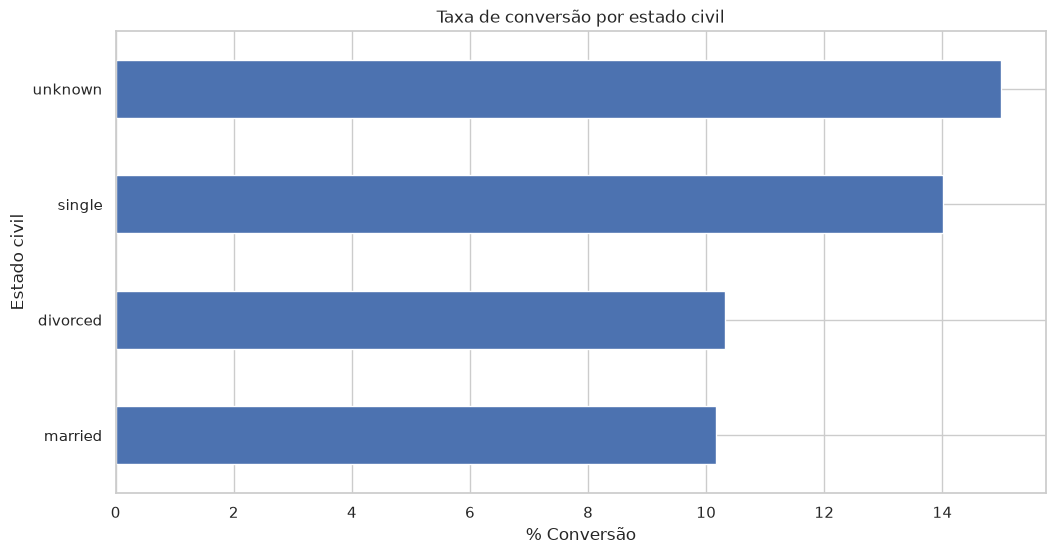

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [ ]:
#Taxa de conversão por estado civil
plt.figure(figsize=(12,6))

(
    pd.crosstab(
         df["marital"],
        df["y"],
        normalize="index"
    )["yes"]
    *100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por estado civil")
plt.xlabel("% Conversão")
plt.ylabel("Estado civil")
plt.show()

df["marital"].value_counts()

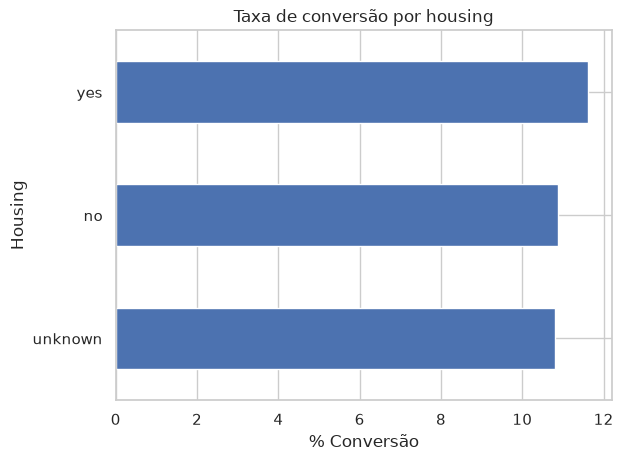

In [ ]:
#Taxa de conversão por housing 
(
    pd.crosstab(
        df["housing"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por housing")
plt.xlabel("% Conversão")
plt.ylabel("Housing")
plt.show()

As taxas de conversão observadas entre as categorias de housing (financiamento imobiliário) apresentaram diferenças pouco significativas, poderão ser removidas do arquivo final.

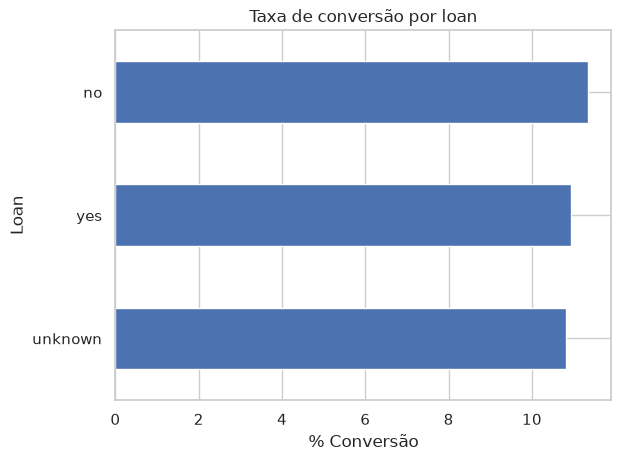

In [ ]:
#Taxa de conversão por loan
(
    pd.crosstab(
        df["loan"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por loan")
plt.xlabel("% Conversão")
plt.ylabel("Loan")
plt.show()

As taxas de conversão observadas entre as categorias de loan (empréstimo pessoal) apresentaram diferenças pouco significativas, poderão ser removidas do arquivo final.

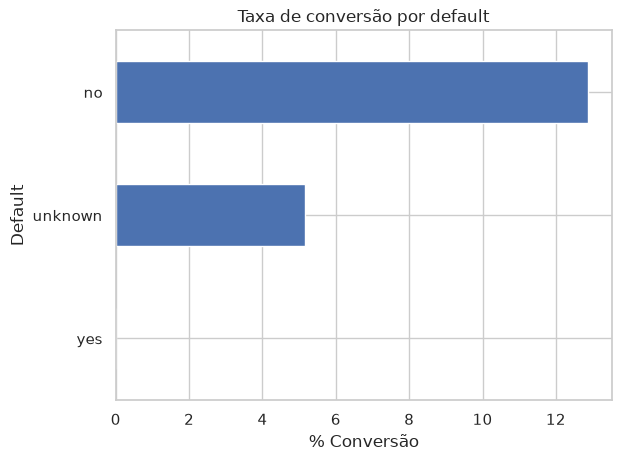

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [ ]:
#Taxa de conversão por default
(
    pd.crosstab(
        df["default"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por default")
plt.xlabel("% Conversão")
plt.ylabel("Default")
plt.show()

df["default"].value_counts()

Apenas 3 registros de clientes com default (inadimplência) "yes", sem representatividade estatística.

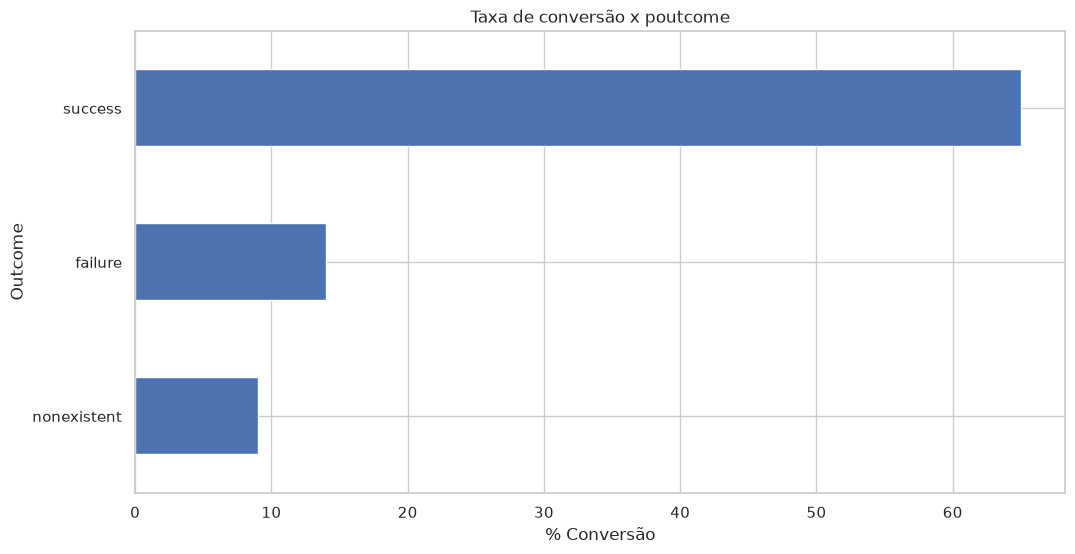

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [ ]:
#Taxa de conversão por resultado da campanha anterior
plt.figure(figsize=(12,6))

(
    pd.crosstab(
        df["poutcome"],
        df["y"],
        normalize="index"
    ).round(2)["yes"]
    *100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por resultado da campanha anterior")
plt.xlabel("% Conversão")
plt.ylabel("Resultados")
plt.show()

O resultado da campanha anterior apresenta relação positiva relevante com a taxa de conversão.

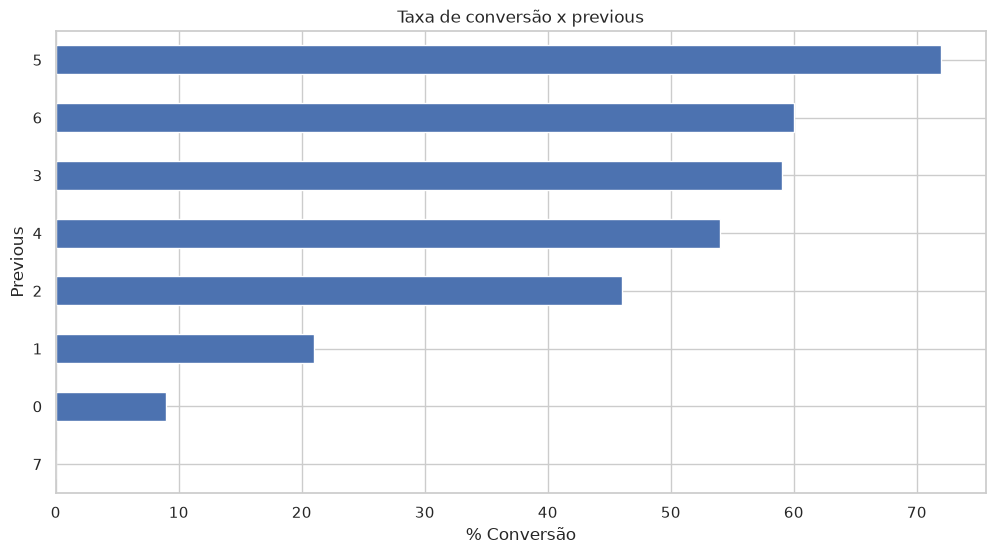

In [ ]:
#Taxa de conversão por numero de contatos anteriores
plt.figure(figsize=(12,6))

(
    pd.crosstab(
        df["previous"],
        df["y"],
        normalize="index"
    ).round(2)["yes"]
    *100
).sort_values().plot(kind="barh")

plt.title("Taxa de conversão por numero de contatos anteriores")
plt.xlabel("% Conversão")
plt.ylabel("Interações")
plt.show()

A quantidade de contatos realizados anteriormente apresenta relação positiva relevante com a taxa de conversão, quanto maior a quantidade de conta, maior a chance de conversão.